# Subsystem Discovery Notebook

This notebook implements the subsystem discovery process for the Legacy MUD codebase. It uses multi-dimensional clustering approaches to identify coherent subsystems in the code.

## Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from loguru import logger as log
from pathlib import Path
from collections import defaultdict, Counter
from typing import Set, Dict, List, Tuple, Any

PROJECT_ROOT = Path('../..').resolve()  # Adjust as needed to find the project root

import legacy_common.subsystem_utils as su
import legacy_common.structural_clustering as sc
import legacy_common.semantic_clustering as sec
import usage_clustering as uc
import legacy_common.cluster_integration as ci
import legacy_common.doc_db as doc_db

## Load Resources

In [ ]:
# Define paths
GRAPH_PATH = su.DEFAULT_GRAPH_PATH
DB_PATH = su.DEFAULT_DB_PATH

# Create directories if they don't exist
os.makedirs(su.INTERNAL_DIR, exist_ok=True)

# Load graph - graph is now a MultiDiGraph
log.info(f"Loading graph from {GRAPH_PATH}...")
graph = su.load_graph(GRAPH_PATH)
log.info(f"Loaded graph with {len(graph.nodes())} nodes and {len(graph.edges())} edges.")

# Load entity database
log.info(f"Loading entity database from {DB_PATH}...")
entity_db = su.load_entity_db(DB_PATH)
log.info(f"Loaded entity database with {len(entity_db.entities)} entries.")

# Load document database
log.info("Loading document database...")
from legacy_common.doc_db import docs_db
log.info(f"Loaded document database with {len(docs_db)} entries.")

# Print edge types distribution to see the relationship types present in the graph
edge_types = {}
for u, v, data in graph.edges(data=True):
    edge_type = data.get('type', 'unknown')
    edge_types[edge_type] = edge_types.get(edge_type, 0) + 1

print("\nEdge type distribution:")
for edge_type, count in sorted(edge_types.items(), key=lambda x: x[1], reverse=True):
    print(f"{edge_type}: {count} edges ({count/len(graph.edges())*100:.2f}%)")

2025-06-24 15:33:58.748 | INFO     | __main__:<module>:9 - Loading graph from /Users/qte2333/repos/legacy/projects/doc_gen/internal/code_graph.gml...


2025-06-24 15:34:00.941 | INFO     | doxygen_graph:load_graph:606 - Graph loaded from /Users/qte2333/repos/legacy/projects/doc_gen/internal/code_graph.gml, nodes: 14507, edges: 60898
2025-06-24 15:34:01.189 | INFO     | __main__:<module>:11 - Loaded graph with 4549 nodes and 45484 edges.
2025-06-24 15:34:01.189 | INFO     | __main__:<module>:14 - Loading entity database from /Users/qte2333/repos/legacy/projects/doc_gen/internal/code_graph.json...
2025-06-24 15:34:01.189 | INFO     | __main__:<module>:11 - Loaded graph with 4549 nodes and 45484 edges.
2025-06-24 15:34:01.189 | INFO     | __main__:<module>:14 - Loading entity database from /Users/qte2333/repos/legacy/projects/doc_gen/internal/code_graph.json...
2025-06-24 15:34:01.591 | INFO     | __main__:<module>:16 - Loaded entity database with 5305 entries.
2025-06-24 15:34:01.592 | INFO     | __main__:<module>:19 - Loading document database...
2025-06-24 15:34:01.591 | INFO     | __main__:<module>:16 - Loaded entity database with 53


Edge type distribution:
calls: 22890 edges (50.33%)
uses: 19976 edges (43.92%)
contained_by: 2565 edges (5.64%)
inherits: 53 edges (0.12%)


## Phase 1: Multi-Dimensional Clustering

### 1.1 Structural Clustering

Apply community detection algorithms to the dependency graph.

In [8]:
# Run structural clustering using Leiden algorithm
log.info("Running structural clustering...")
etypes = ('calls', 'uses')

def calc_utility_score(score: Dict[str, float]) -> bool:
    return (
        ((
            sum(score[f'fan_in_{etype}'] for etype in etypes) +
            sum(score[f'fan_in_clusters_{etype}'] for etype in etypes) +
            0
        )/2) 
        * 
        (1-(
            sum(score[f'fan_out_{etype}'] for etype in etypes) + # calls, uses, inherits
            sum(score[f'fan_out_clusters_{etype}'] for etype in etypes) +
            sum(score[f'overlap_{etype}'] for etype in etypes) + # overlap - higher value means more used outside its cluster
            0
        )/2)
    )

structural_clustering, structural_metadata = sc.run_structural_clustering(
    graph,
    utility_threshold_fn=lambda score: calc_utility_score(score) > 0.226,
    filter_utilities=True,
    resolution=1.0
)
log.info(f"Generated {structural_metadata['refined_cluster_count']} structural clusters.")

# Convert to cluster objects
structural_clusters = sc.clustering_to_cluster_objects(structural_clustering)

2025-06-24 15:38:23.674 | INFO     | __main__:<module>:2 - Running structural clustering...
2025-06-24 15:38:23.703 | INFO     | structural_clustering:run_structural_clustering:15 - Starting structural clustering on graph with 4549 nodes and 45484 edges
2025-06-24 15:38:23.704 | INFO     | structural_clustering:run_structural_clustering:16 - Configuration: algorithm=leiden, filter_utilities=True, resolution=1.0
2025-06-24 15:38:23.703 | INFO     | structural_clustering:run_structural_clustering:15 - Starting structural clustering on graph with 4549 nodes and 45484 edges
2025-06-24 15:38:23.704 | INFO     | structural_clustering:run_structural_clustering:16 - Configuration: algorithm=leiden, filter_utilities=True, resolution=1.0
2025-06-24 15:38:23.704 | INFO     | structural_clustering:run_structural_clustering:18 - Stage 1: Initial clustering (including utility nodes)
2025-06-24 15:38:23.704 | INFO     | structural_clustering:run_structural_clustering:18 - Stage 1: Initial clustering 

In [ ]:
from pydoc import doc
import legacy_common.doxygen_graph as dg
refs = list(dg.compose_structural_reference_list(entity_db))
refs.extend(dg.compose_codeline_reference_list(entity_db))
ref_dict = {}
for ref in refs:
    ref_dict.setdefault(ref[2], set()).add((str(ref[0]), ref[1]))

eid = "set-stat_8cc_1a59f23736144bd6fcbae1d36188068cb1"

for tag in ref_dict:
    print(f"{tag:>20}: in: {len([r for r in ref_dict[tag] if r[1] == eid]):>3}, out: {len([r for r in ref_dict[tag] if r[0] == eid]):>3}, total: {len(ref_dict[tag])}")
print(graph.in_degree(eid.rsplit("_", 1)[1], 0))
print(graph.out_degree(eid.rsplit("_", 1)[1], 0))

            includes: in:   0, out:   0, total: 1780
      innernamespace: in:   0, out:   0, total: 61
          includedby: in:   0, out:   0, total: 1656
           innerfile: in:   0, out:   0, total: 217
          innerclass: in:   0, out:   0, total: 176
                 ref: in:   2, out: 134, total: 38530
     basecompoundref: in:   0, out:   0, total: 30
              member: in:   0, out:   0, total: 1279
  derivedcompoundref: in:   0, out:   0, total: 24
            innerdir: in:   0, out:   0, total: 19
        _in_compound: in:   0, out:   1, total: 4836
        referencedby: in: 157, out:   1, total: 26770
          references: in:   1, out: 129, total: 27937
        reimplements: in:   0, out:   0, total: 23
     reimplementedby: in:   0, out:   0, total: 23
1
216


In [ ]:
with open("utility_scores.json", "r") as f:
    utility_score = json.load(f)
# Get nodes above threshold
etypes = ('calls', 'uses')


def calc_utility_score(score: Dict[str, float]) -> bool:
    return (
        ((
            sum(score[f'fan_in_{etype}'] for etype in etypes) +
            sum(score[f'fan_in_clusters_{etype}'] for etype in etypes) +
            0
        )/2) 
        * 
        (1-(
            sum(score[f'fan_out_{etype}'] for etype in etypes) + # calls, uses, inherits
            sum(score[f'fan_out_clusters_{etype}'] for etype in etypes) +
            sum(score[f'overlap_{etype}'] for etype in etypes) + # overlap - higher value means more used outside its cluster
            0
        )/2)
    )

for node, score in utility_score.items():

    # score['sum'] = (
    #     (1-score['in']) *
    #     score['out'] *
    #     (1-score['between']) *
    #     score['unique_fan_out'] *
    #     (1-score['unique_fan_in'])
    # )

    # score['sum'] = ((
    #     sum(utility_score[node][f'fan_in_{etype}'] for etype in etypes) +
    #     sum(utility_score[node][f'fan_in_clusters_{etype}'] for etype in etypes) +
    #     0
    # ) - (
    #     sum(utility_score[node][f'fan_out_{etype}'] for etype in etypes) + # calls, uses, inherits
    #     sum(utility_score[node][f'fan_out_clusters_{etype}'] for etype in etypes) +
    #     utility_score[node]['between'] +
    #     # overlap of 0 means no common between inside and outside cluster usage, overlap of 1 means all usage is inside the cluster
    #     sum(utility_score[node][f'overlap_{etype}'] for etype in etypes) + # overlap - higher value means more used outside its cluster
    #     0
    # ))# / (6 * len(etypes))  # Normalize

    score['sum'] = calc_utility_score(score)
#        utility_score[node]['between'] +
        # overlap of 0 means no common between inside and outside cluster usage, overlap of 1 means all usage is inside the cluster
#        0
#    )
#    )# / (6 * len(etypes))  # Normalize

nodes = {node: score for node, score in utility_score.items() if score['sum'] >= 0.05}
nodes = sorted(nodes.items(), key=lambda x: x[1]['sum'], reverse=True)
print(f"{'sum':>6} {'cin':>5} {'uin':>5} {'cout':>5} {'uout':>5} {'Ccin':>5} {'Cuin':>5} {'Ccout':>5} {'Cuout':>5} {'Oc':>5} {'Ou':>5} {'BT':>5} - [kind] name")
for node, score in nodes:
    print(
        f" {score['sum']:0.3f}  "
        f"{score['fan_in_calls']:0.2f}  {score['fan_in_uses']:0.2f}  "
        f"{score['fan_out_calls']:0.2f}  {score['fan_out_uses']:0.2f}  "
        f"{score['fan_in_clusters_calls']:0.2f}  {score['fan_in_clusters_uses']:0.2f}  "
        f"{score['fan_out_clusters_calls']:0.2f}  {score['fan_out_clusters_uses']:0.2f}  "
        f"{score['overlap_calls']:0.2f}  {score['overlap_uses']:0.2f}  "
        f"{score['between']:0.2f} "
        f"- [{graph.nodes[node].get('kind')}] {graph.nodes[node].get('name')}"
    )


   sum   cin   uin  cout  uout  Ccin  Cuin Ccout Cuout    Oc    Ou    BT - [kind] name
 0.930  0.00  0.95  0.00  0.01  0.05  1.00  0.00  0.08  0.00  0.05  0.00 - [class] String
 0.675  0.58  0.00  0.01  0.01  0.89  0.05  0.06  0.08  0.06  0.00  0.00 - [function] bool Character::is_npc() const
 0.639  0.44  0.00  0.01  0.01  0.95  0.05  0.06  0.08  0.06  0.00  0.00 - [function] bool Flags::has(const Flags::Bit &b) const
 0.632  0.00  0.48  0.00  0.00  0.05  0.73  0.00  0.00  0.00  0.00  0.00 - [enum] Bit
 0.591  0.30  0.00  0.00  0.01  0.89  0.05  0.00  0.08  0.00  0.00  0.00 - [function] World & Game::world()
 0.548  0.40  0.00  0.01  0.01  0.79  0.05  0.06  0.08  0.07  0.00  0.00 - [function] const char * one_argument(const String &argument, String &arg)
 0.520  0.40  0.00  0.01  0.01  0.74  0.05  0.06  0.08  0.07  0.00  0.00 - [function] int Format::sprintf(char *buf, const String &fmt, Params &&... params)
 0.482  0.31  0.00  0.01  0.01  0.74  0.05  0.06  0.08  0.07  0.00  0.00 - [d

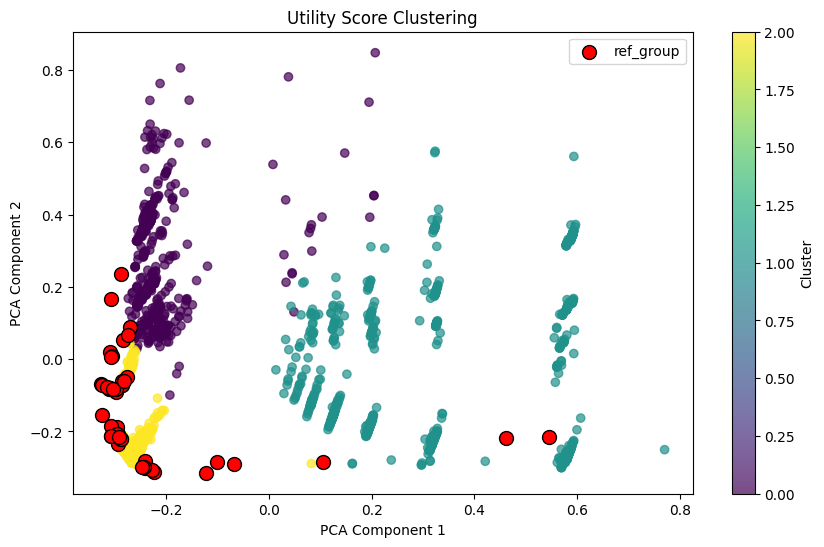

Top features differentiating group 2 from groups 0 and 1:
overlap_calls: group 2 = 0.017, groups 0/1 avg = 0.263, diff = -0.247
    Group 0: 25th=0.250, 50th=0.333, 75th=0.500
    Group 1: 25th=0.000, 50th=0.000, 75th=0.333
    Group 2: 25th=0.000, 50th=0.000, 75th=0.000
overlap_uses: group 2 = 0.001, groups 0/1 avg = 0.179, diff = -0.178
    Group 0: 25th=0.000, 50th=0.000, 75th=0.000
    Group 1: 25th=0.250, 50th=0.333, 75th=0.500
    Group 2: 25th=0.000, 50th=0.000, 75th=0.000
fan_out_clusters_uses: group 2 = 0.080, groups 0/1 avg = 0.250, diff = -0.171
    Group 0: 25th=0.083, 50th=0.167, 75th=0.333
    Group 1: 25th=0.167, 50th=0.250, 75th=0.333
    Group 2: 25th=0.000, 50th=0.083, 75th=0.083
fan_out_clusters_calls: group 2 = 0.044, groups 0/1 avg = 0.192, diff = -0.148
    Group 0: 25th=0.062, 50th=0.125, 75th=0.250
    Group 1: 25th=0.062, 50th=0.188, 75th=0.250
    Group 2: 25th=0.000, 50th=0.000, 75th=0.062
fan_out_uses: group 2 = 0.020, groups 0/1 avg = 0.118, diff = -0.098
 

In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def cluster_and_visualize_utility_scores(utility_score, ref_group: List[str]) -> pd.DataFrame:
    # Convert utility_score to a DataFrame
    df = pd.DataFrame.from_dict(utility_score, orient='index')
    
    # Normalize the scores
    scaler = MinMaxScaler()
    normalized_scores = scaler.fit_transform(df[[
        f'fan_in_{etype}' for etype in ['calls', 'uses']] +
        [f'fan_out_{etype}' for etype in ['calls', 'uses']] +
        [f'fan_in_clusters_{etype}' for etype in ['calls', 'uses']] +
        [f'fan_out_clusters_{etype}' for etype in ['calls', 'uses']] +
        [f'overlap_{etype}' for etype in ['calls', 'uses']] +
        ['between']
#        'overlap'
    ])
    
    # Apply clustering (e.g., K-Means)
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(normalized_scores)
    df['cluster'] = clusters
    
    # Reduce dimensions for visualization
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(normalized_scores)
    
    # Plot the clusters
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='viridis', alpha=0.7)
    # Highlight nodes in ref_group
    ref_indices = [i for i, node_id in enumerate(df.index) if node_id in ref_group]
    plt.scatter(reduced_data[ref_indices, 0], reduced_data[ref_indices, 1], 
                c='red', edgecolor='black', s=100, label='ref_group', marker='o')
    plt.legend()
    plt.colorbar(scatter, label='Cluster')
    plt.title('Utility Score Clustering')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.show()
    
    return df

ref_group = []
with open("utility_scores.json", "r") as f:
    utility_score = json.load(f)
    for node in utility_score:
        utility_score[node]['sum'] = calc_utility_score(utility_score[node])
        if utility_score[node]['sum'] > 0.228:
            ref_group.append(node)

clustered_df = cluster_and_visualize_utility_scores(utility_score, ref_group)
# Identify key features that differentiate group 2 from groups 0 and 1

# Get feature columns used for clustering
feature_cols = [
    f'fan_in_{etype}' for etype in ['calls', 'uses']
] + [
    f'fan_out_{etype}' for etype in ['calls', 'uses']
] + [
    f'fan_in_clusters_{etype}' for etype in ['calls', 'uses']
] + [
    f'fan_out_clusters_{etype}' for etype in ['calls', 'uses']
] + [
    f'overlap_{etype}' for etype in ['calls', 'uses']
] + [
    'between'
]

# Compute mean feature values for each cluster
group_means = clustered_df.groupby('cluster')[feature_cols].mean()

# Compute the difference between group 2 and the average of groups 0 and 1
mean_01 = group_means.loc[[0, 1]].mean()
diff = group_means.loc[2] - mean_01

# Sort features by absolute difference
diff_sorted = diff.abs().sort_values(ascending=False)

print("Top features differentiating group 2 from groups 0 and 1:")
for feature in diff_sorted.index[:10]:
    print(f"{feature}: group 2 = {group_means.loc[2][feature]:.3f}, groups 0/1 avg = {mean_01[feature]:.3f}, diff = {diff[feature]:+.3f}")
    for group in [0, 1, 2]:
        percentiles = clustered_df[clustered_df['cluster'] == group][feature].quantile([0.25, 0.5, 0.75])
        print(f"    Group {group}: 25th={percentiles.loc[0.25]:.3f}, 50th={percentiles.loc[0.5]:.3f}, 75th={percentiles.loc[0.75]:.3f}")




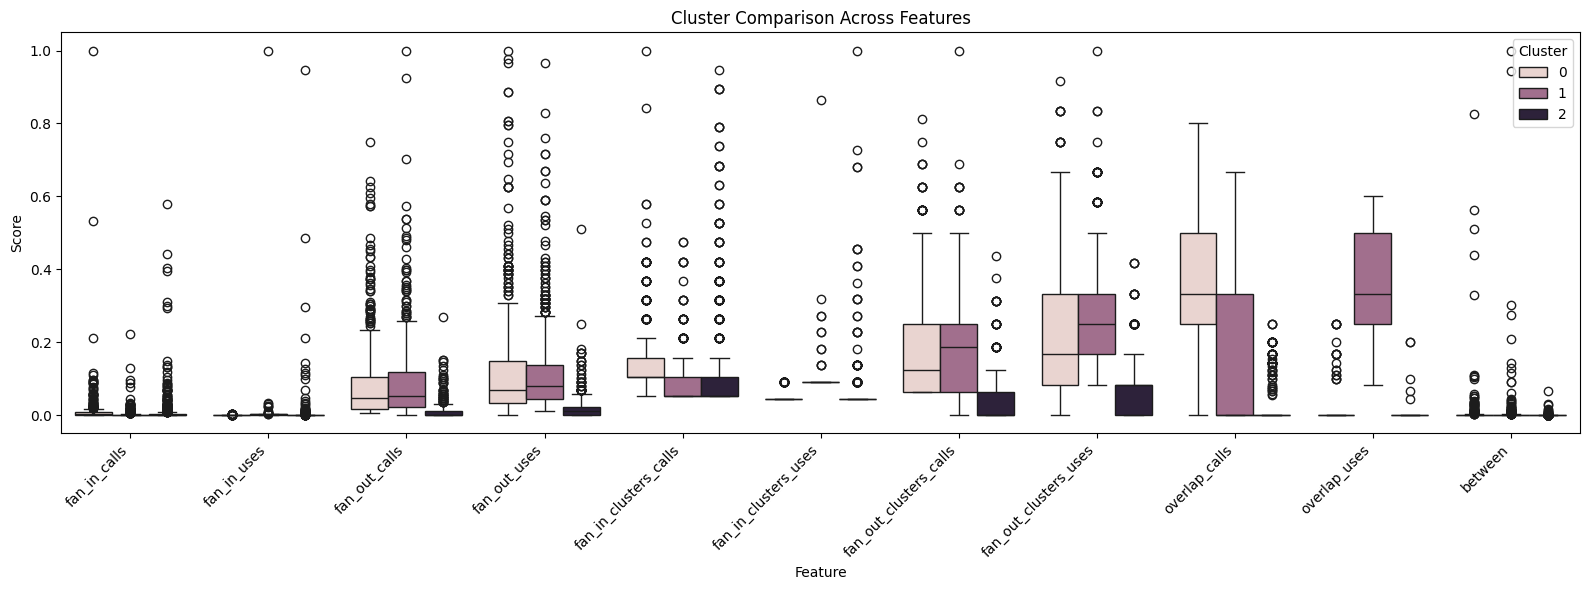

In [37]:
import seaborn as sns

feature_columns = (
    [f'fan_in_{etype}' for etype in ['calls', 'uses']] +
    [f'fan_out_{etype}' for etype in ['calls', 'uses']] +
    [f'fan_in_clusters_{etype}' for etype in ['calls', 'uses']] + 
    [f'fan_out_clusters_{etype}' for etype in ['calls', 'uses']] +
    [f'overlap_{etype}' for etype in ['calls', 'uses']] +
    ['between']
)

def plot_cluster_feature_distributions(df: pd.DataFrame):
    # Combine into long-form DataFrame
    df_melted = pd.melt(df.reset_index(), 
                        id_vars=['index', 'cluster'], 
                        value_vars=feature_columns,
                        var_name='Feature', 
                        value_name='Score')

    # Plot
    plt.figure(figsize=(16, 6))
    sns.boxplot(data=df_melted, x='Feature', y='Score', hue='cluster')
    plt.xticks(rotation=45, ha='right')
    plt.title('Cluster Comparison Across Features')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

plot_cluster_feature_distributions(clustered_df)

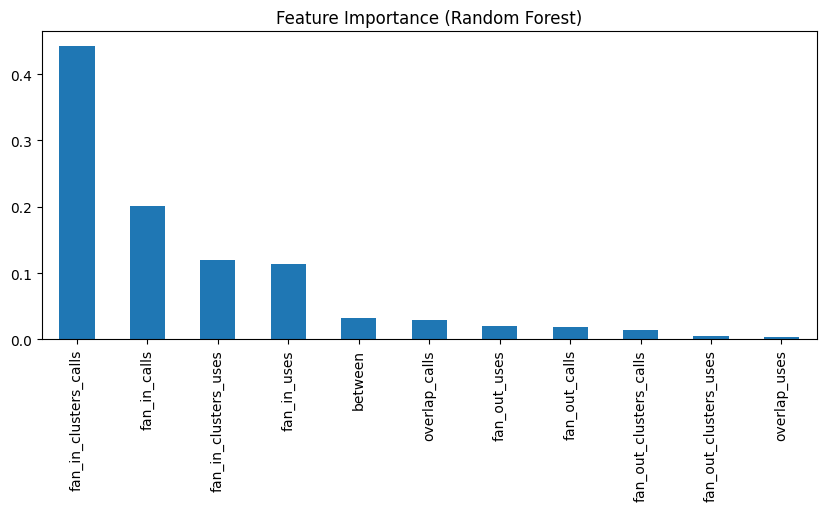

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

def rank_feature_importance(df, ref_group, feature_columns):
    y = df.index.isin(ref_group).astype(int)
    X = df[feature_columns]
    
    model = RandomForestClassifier(n_estimators=100, random_state=0)
    model.fit(X, y)
    
    importances = pd.Series(model.feature_importances_, index=feature_columns)
    importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 4), title='Feature Importance (Random Forest)')

rank_feature_importance(clustered_df, ref_group, feature_columns)

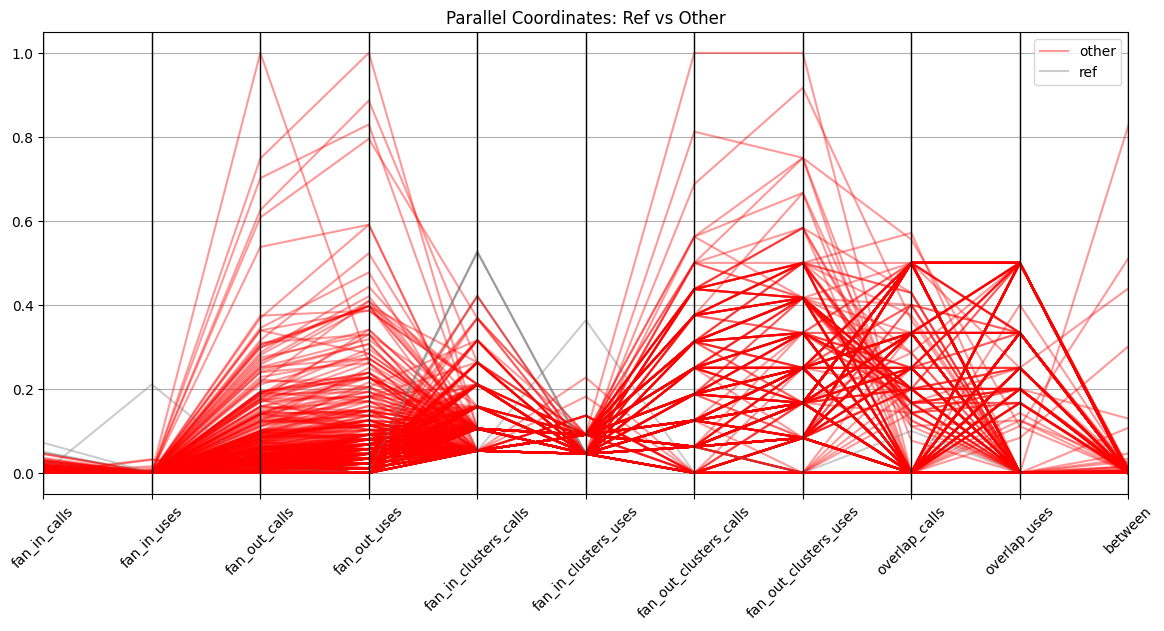

In [40]:
from pandas.plotting import parallel_coordinates

def plot_parallel_coordinates(df, ref_group, feature_columns):
    df_copy = df.copy()
    df_copy['label'] = df_copy.index.map(lambda x: 'ref' if x in ref_group else 'other')
    sample_df = df_copy[feature_columns + ['label']].sample(frac=0.2, random_state=42)
    plt.figure(figsize=(14, 6))
    parallel_coordinates(sample_df, 'label', color=['red', 'gray'], alpha=0.4)
    plt.title('Parallel Coordinates: Ref vs Other')
    plt.xticks(rotation=45)
    plt.show()

plot_parallel_coordinates(clustered_df, ref_group, feature_columns)

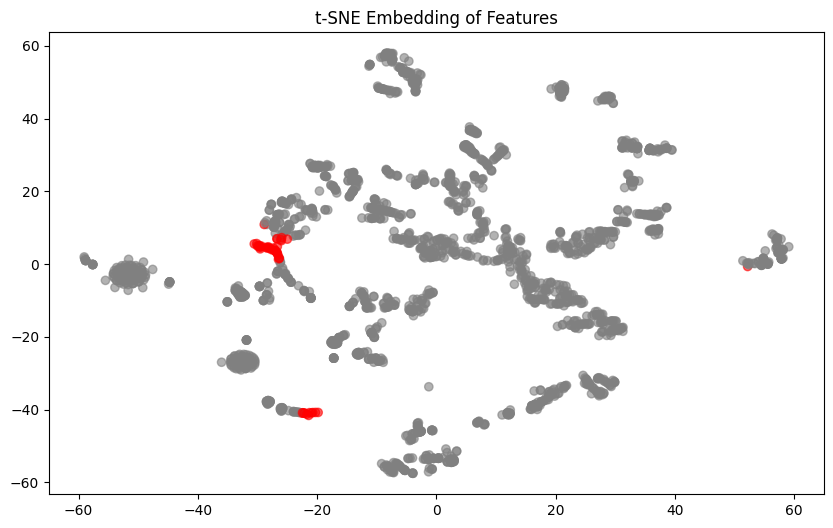

In [41]:
from sklearn.manifold import TSNE

def tsne_plot(df, feature_columns, ref_group):
    X = df[feature_columns]
    tsne = TSNE(n_components=2, random_state=42)
    X_embedded = tsne.fit_transform(X)
    colors = ['red' if idx in ref_group else 'gray' for idx in df.index]
    plt.figure(figsize=(10, 6))
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=colors, alpha=0.6)
    plt.title('t-SNE Embedding of Features')
    plt.show()

tsne_plot(clustered_df, feature_columns, ref_group)

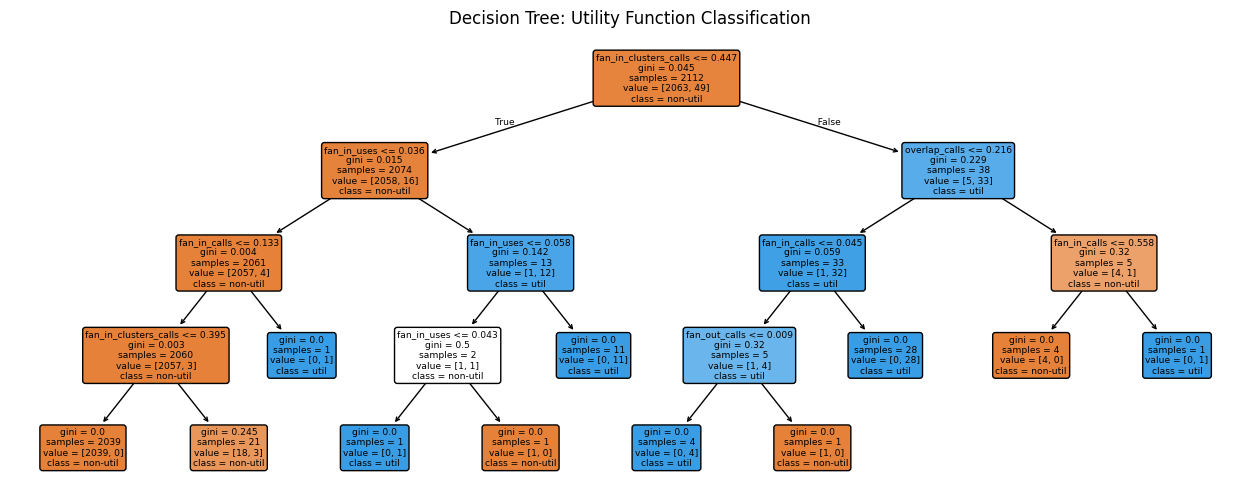

Decision Rules:
 |--- fan_in_clusters_calls <= 0.45
|   |--- fan_in_uses <= 0.04
|   |   |--- fan_in_calls <= 0.13
|   |   |   |--- fan_in_clusters_calls <= 0.39
|   |   |   |   |--- class: 0
|   |   |   |--- fan_in_clusters_calls >  0.39
|   |   |   |   |--- class: 0
|   |   |--- fan_in_calls >  0.13
|   |   |   |--- class: 1
|   |--- fan_in_uses >  0.04
|   |   |--- fan_in_uses <= 0.06
|   |   |   |--- fan_in_uses <= 0.04
|   |   |   |   |--- class: 1
|   |   |   |--- fan_in_uses >  0.04
|   |   |   |   |--- class: 0
|   |   |--- fan_in_uses >  0.06
|   |   |   |--- class: 1
|--- fan_in_clusters_calls >  0.45
|   |--- overlap_calls <= 0.22
|   |   |--- fan_in_calls <= 0.05
|   |   |   |--- fan_out_calls <= 0.01
|   |   |   |   |--- class: 1
|   |   |   |--- fan_out_calls >  0.01
|   |   |   |   |--- class: 0
|   |   |--- fan_in_calls >  0.05
|   |   |   |--- class: 1
|   |--- overlap_calls >  0.22
|   |   |--- fan_in_calls <= 0.56
|   |   |   |--- class: 0
|   |   |--- fan_in_calls >

In [44]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt
import pandas as pd

def extract_utility_decision_rules(df: pd.DataFrame, ref_group: list[str], feature_columns: list[str], max_depth: int = 4):
    # Create binary target label: 1 if in ref_group, else 0
    y = df.index.isin(ref_group).astype(int)
    X = df[feature_columns]

    # Fit decision tree classifier
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    clf.fit(X, y)

    # Plot the tree
    plt.figure(figsize=(16, 6))
    plot_tree(clf, 
              feature_names=feature_columns, 
              class_names=['non-util', 'util'], 
              filled=True, rounded=True)
    plt.title('Decision Tree: Utility Function Classification')
    plt.show()

    # Print textual rules
    rules = export_text(clf, feature_names=feature_columns)
    print("Decision Rules:\n", rules)

    return clf

clf = extract_utility_decision_rules(clustered_df, ref_group, feature_columns, max_depth=4)

In [45]:
# Get predicted labels for all nodes
df = clustered_df.copy()
df['predicted_utility'] = clf.predict(df[feature_columns])
df['utility_confidence'] = clf.predict_proba(df[feature_columns])[:, 1]

In [48]:
df[df['predicted_utility'] == 1]


,between,fan_in_calls,fan_in_clusters_calls,fan_out_calls,fan_out_clusters_calls,overlap_calls,fan_in_uses,fan_in_clusters_uses,fan_out_uses,fan_out_clusters_uses,...,overlap_inherits,fan_in_includes,fan_in_clusters_includes,fan_out_includes,fan_out_clusters_includes,overlap_includes,sum,cluster,predicted_utility,utility_confidence
1ab1a353a8fccef0129c7233ee40504360,7.786872e-04,0.441498,0.947368,0.005848,0.0625,0.055556,0.000000,0.045455,0.011364,0.083333,...,0.0,0,1.0,0,0,0.0,0.638775,2,1,1.0
1a53bc6a69388131048a4da1cfd29c27b0,4.041015e-04,0.396256,0.736842,0.005848,0.0625,0.071429,0.000000,0.045455,0.011364,0.083333,...,0.0,0,1.0,0,0,0.0,0.520191,2,1,1.0
1adbff41fc88251e2cbaa9119e751cd7f2,1.184764e-03,0.079563,0.526316,0.017544,0.1250,0.200000,0.000000,0.045455,0.011364,0.083333,...,0.0,0,1.0,0,0,0.0,0.254469,2,1,1.0
1a5898d719b3829123ad7cd32e57d385ae,3.647967e-05,0.023401,0.473684,0.005848,0.0625,0.111111,0.000000,0.045455,0.011364,0.083333,...,0.0,0,1.0,0,0,0.0,0.234085,2,1,1.0
1a0ab42ce2c31d3c6f47779ad26cbec45a,2.731189e-04,0.104524,0.789474,0.005848,0.0625,0.066667,0.000000,0.045455,0.011364,0.083333,...,0.0,0,1.0,0,0,0.0,0.415775,2,1,1.0
1a34b9bfd8b34ab78d8568053cd253e370,2.389559e-03,0.223089,0.473684,0.005848,0.0625,0.000000,0.000885,0.090909,0.022727,0.166667,...,0.0,0,1.0,0,0,0.0,0.244901,1,1,1.0
1a6f747eda6b1bc184c8a89badb0b9e56e,5.005727e-04,0.294852,0.894737,0.011696,0.1250,0.117647,0.000000,0.045455,0.022727,0.166667,...,0.0,0,1.0,0,0,0.0,0.480513,2,1,1.0
1adc99d74487127d7d20bf3432107518a7,2.764656e-02,0.533541,0.578947,0.011696,0.1250,0.181818,0.000000,0.045455,0.079545,0.333333,...,0.0,0,1.0,0,0,0.0,0.367244,0,1,1.0
1af06eefda2f507004ace67b7a912ac939,1.338936e-04,0.000000,0.052632,0.000000,0.0000,0.000000,0.484956,0.727273,0.000000,0.000000,...,0.0,0,1.0,0,0,0.0,0.632430,2,1,1.0
1a44a9ee6173f691bbb04ed54082936096,1.664695e-03,0.299532,0.894737,0.000000,0.0000,0.000000,0.000000,0.045455,0.011364,0.083333,...,0.0,0,1.0,0,0,0.0,0.590512,2,1,1.0


In [69]:
for node_id in clustered_df[clustered_df['cluster'] == 1].index:
    node_data = graph.nodes[node_id]
    node_name = node_data.get('name', node_id)
    node_kind = node_data.get('type', 'unknown')
    print(f"{node_id}: {node_name} ({node_kind})")


1ab5e1fadba25cf9f57abdcdbbf9db42e5: void Garbage::make_garbage() (member)
1ab7e15fb30268e94e2f8fdcd4a78314b3: worldmap::Quadtree< T >::Quadtree(const Quadtree &) (member)
1a256688a2c221cf2a7a5c4c9664ef3640: virtual War::Opponent::~Opponent() (member)
1a00b8ca08b66224619497d4001a63d329: Dispatcher & event::Dispatcher::operator=(const Dispatcher &) (member)
1aab505fda8758785f12f56f1d84201324: MobProgActList::MobProgActList(const MobProgActList &) (member)
1af27892b3f927a51de868d5b01d9f035f: static const char * parse_object(cJSON *item, const char *value, const char **ep) (member)
1a5985d848191d3b27193b8dd5f715c8ad: cJSON * cJSON_CreateStringArray(const char **strings, int count) (member)
1aa428c0b280cb4e9f2f6d924b82d19dcc: void affect::remove_marked_from_char(Character *ch) (member)
1a70103d7a7b2414831ad8e4e79ed7c85a: cJSON * cJSON_DetachItemFromArray(cJSON *array, int which) (member)
1a583975fdd7380b8ecc8b273ccc275ab6: void insert_storagedata(StoredPlayer *newdata) (member)
1a2f216d91c7

In [9]:
# Save structural clusters
STRUCTURAL_CLUSTERS_PATH = su.INTERNAL_DIR / "structural_clusters.json"
su.save_clusters(structural_clusters, STRUCTURAL_CLUSTERS_PATH, metadata=structural_metadata)
print(f"Saved structural clusters to {STRUCTURAL_CLUSTERS_PATH}")

Saved structural clusters to /Users/qte2333/repos/legacy/projects/doc_gen/internal/structural_clusters.json


In [10]:
# Basic statistics on structural clusters
print(f"Number of structural clusters: {len(structural_clusters)}")
cluster_sizes = [len(c.nodes) for c in structural_clusters.values()]
print(f"Average cluster size: {np.mean(cluster_sizes):.2f} entities")
print(f"Minimum cluster size: {min(cluster_sizes)} entities")
print(f"Maximum cluster size: {max(cluster_sizes)} entities")
print(f"Modularity: {structural_metadata.get('modularity', 'N/A')}")

Number of structural clusters: 105
Average cluster size: 43.32 entities
Minimum cluster size: 1 entities
Maximum cluster size: 517 entities
Modularity: N/A


2025-06-23 18:09:50.675 | INFO     | structural_clustering:run_structural_clustering:296 - Starting structural clustering on graph with 4549 nodes and 36002 edges
2025-06-23 18:09:50.675 | INFO     | structural_clustering:run_structural_clustering:297 - Configuration: algorithm=leiden, utility_threshold=0.05, filter_utilities=True, resolution=1.0
2025-06-23 18:09:50.675 | INFO     | structural_clustering:run_structural_clustering:297 - Configuration: algorithm=leiden, utility_threshold=0.05, filter_utilities=True, resolution=1.0
2025-06-23 18:09:50.676 | INFO     | structural_clustering:run_structural_clustering:307 - Stage 1: Initial clustering (including utility nodes)
2025-06-23 18:09:50.676 | INFO     | structural_clustering:run_structural_clustering:307 - Stage 1: Initial clustering (including utility nodes)
2025-06-23 18:09:50.755 | INFO     | structural_clustering:apply_leiden_clustering:131 - Applying Leiden clustering with resolution=1.0 on graph with 4549 nodes and 35713 edge

Running modified structural clustering...


2025-06-23 18:09:51.508 | INFO     | structural_clustering:apply_leiden_clustering:165 - Leiden clustering completed in 0.75s. Found 54 communities
2025-06-23 18:09:51.509 | INFO     | structural_clustering:identify_utility_nodes:13 - Identifying utility nodes with threshold 0.05
2025-06-23 18:09:51.510 | INFO     | structural_clustering:identify_utility_nodes:15 - Calculating in/out degree for 4549 nodes
2025-06-23 18:09:51.509 | INFO     | structural_clustering:identify_utility_nodes:13 - Identifying utility nodes with threshold 0.05
2025-06-23 18:09:51.510 | INFO     | structural_clustering:identify_utility_nodes:15 - Calculating in/out degree for 4549 nodes
2025-06-23 18:09:51.511 | INFO     | structural_clustering:identify_utility_nodes:18 - Computing betweenness centrality (this may take a while for large graphs)
2025-06-23 18:09:51.511 | INFO     | structural_clustering:identify_utility_nodes:18 - Computing betweenness centrality (this may take a while for large graphs)
2025-06-

Generated 108 structural clusters.
Number of structural clusters: 108
Average cluster size: 42.12 entities
Minimum cluster size: 1 entities
Maximum cluster size: 544 entities
Modularity: N/A


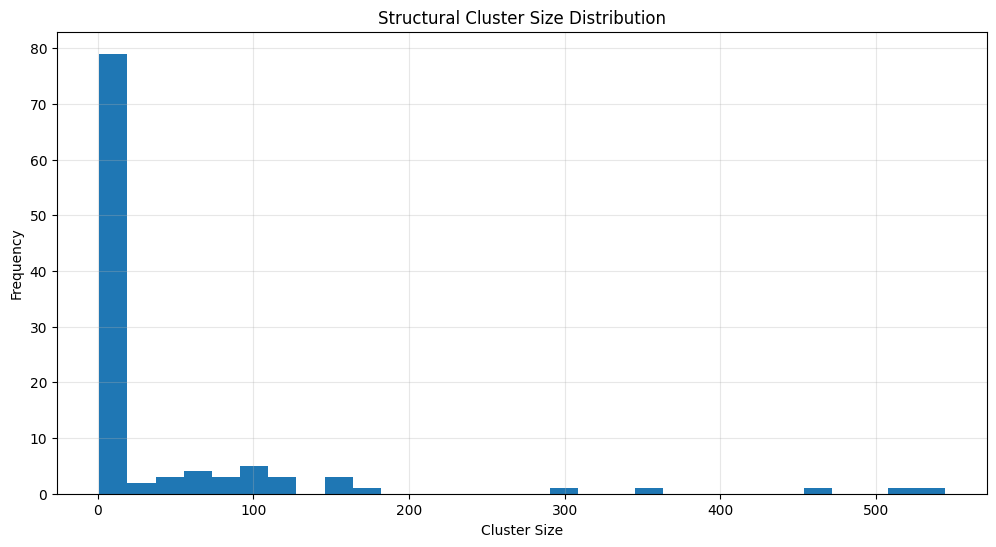

Saved modified structural clusters to /Users/qte2333/repos/legacy/projects/doc_gen/internal/structural_clusters_mod.json


In [11]:
# Test the modified structural clustering
print("Running modified structural clustering...")
structural_clustering_mod, structural_metadata_mod = sc.run_structural_clustering(
    graph,
    utility_threshold=0.05,  # Using a slightly higher threshold
    filter_utilities=True,
    resolution=1.0
)
print(f"Generated {structural_metadata_mod['refined_cluster_count']} structural clusters.")

# Convert to cluster objects
structural_clusters_mod = sc.clustering_to_cluster_objects(structural_clustering_mod)

# Basic statistics on structural clusters
print(f"Number of structural clusters: {len(structural_clusters_mod)}")
cluster_sizes = [len(c.nodes) for c in structural_clusters_mod.values()]
print(f"Average cluster size: {np.mean(cluster_sizes):.2f} entities")
print(f"Minimum cluster size: {min(cluster_sizes)} entities")
print(f"Maximum cluster size: {max(cluster_sizes)} entities")
print(f"Modularity: {structural_metadata_mod.get('modularity', 'N/A')}")

# Plot cluster size distribution
plt.figure(figsize=(12, 6))
plt.hist(cluster_sizes, bins=30)
plt.title("Structural Cluster Size Distribution")
plt.xlabel("Cluster Size")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# Save modified structural clusters
MOD_STRUCTURAL_CLUSTERS_PATH = su.INTERNAL_DIR / "structural_clusters_mod.json"
su.save_clusters(structural_clusters_mod, MOD_STRUCTURAL_CLUSTERS_PATH, metadata=structural_metadata_mod)
print(f"Saved modified structural clusters to {MOD_STRUCTURAL_CLUSTERS_PATH}")

In [12]:
# Debug structural clustering
def debug_structural_clustering():
    print("Analyzing the structural clustering...")
    
    # Examine the utility nodes
    utility_nodes = set()
    # Re-run the identify utility nodes step with verbose output
    try:
        initial_clustering, initial_metadata = sc.run_structural_clustering(
            graph, 
            utility_threshold=0.03,
            filter_utilities=False,  # Don't filter initially
            resolution=1.0
        )
        
        print(f"Initial clustering generated {len(set(initial_clustering.values()))} clusters")
        
        utility_nodes = sc.identify_utility_nodes(graph, initial_clustering, threshold=0.03)
        print(f"Identified {len(utility_nodes)} utility nodes ({len(utility_nodes)/len(graph.nodes())*100:.2f}% of all nodes)")
        
        # Sample some utility nodes
        print("\nSample utility nodes:")
        sample_size = min(10, len(utility_nodes))
        for node_id in list(utility_nodes)[:sample_size]:
            node_data = graph.nodes[node_id]
            node_name = node_data.get('name', node_id)
            node_kind = node_data.get('type', 'unknown')
            print(f"{node_id}: {node_name} ({node_kind})")
            
        # Examine the graph structure
        print("\nGraph structure:")
        print(f"Nodes: {len(graph.nodes())}")
        print(f"Edges: {len(graph.edges())}")
        
        # Check the node degrees
        in_degrees = dict(graph.in_degree())
        out_degrees = dict(graph.out_degree())
        
        in_degree_values = list(in_degrees.values())
        out_degree_values = list(out_degrees.values())
        
        print(f"In-degree: max={max(in_degree_values)}, min={min(in_degree_values)}, avg={sum(in_degree_values)/len(in_degree_values):.2f}")
        print(f"Out-degree: max={max(out_degree_values)}, min={min(out_degree_values)}, avg={sum(out_degree_values)/len(out_degree_values):.2f}")
        
        # Check the distribution of node types
        node_types = {}
        for node, data in graph.nodes(data=True):
            node_type = data.get('type', 'unknown')
            node_types[node_type] = node_types.get(node_type, 0) + 1
        
        print("\nNode type distribution:")
        for node_type, count in node_types.items():
            print(f"{node_type}: {count} nodes ({count/len(graph.nodes())*100:.2f}%)")
        
        # Check edge types
        edge_types = {}
        for u, v, data in graph.edges(data=True):
            edge_type = data.get('type', 'unknown')
            edge_types[edge_type] = edge_types.get(edge_type, 0) + 1
        
        print("\nEdge type distribution:")
        for edge_type, count in edge_types.items():
            print(f"{edge_type}: {count} edges ({count/len(graph.edges())*100:.2f}%)")
        
    except Exception as e:
        print(f"Error in structural clustering analysis: {e}")
    
    return utility_nodes

# Run the debug function
utility_nodes = debug_structural_clustering()

2025-06-23 18:11:20.423 | INFO     | structural_clustering:run_structural_clustering:296 - Starting structural clustering on graph with 4549 nodes and 36002 edges
2025-06-23 18:11:20.423 | INFO     | structural_clustering:run_structural_clustering:297 - Configuration: algorithm=leiden, utility_threshold=0.03, filter_utilities=False, resolution=1.0
2025-06-23 18:11:20.423 | INFO     | structural_clustering:run_structural_clustering:297 - Configuration: algorithm=leiden, utility_threshold=0.03, filter_utilities=False, resolution=1.0
2025-06-23 18:11:20.423 | INFO     | structural_clustering:run_structural_clustering:307 - Stage 1: Initial clustering (including utility nodes)
2025-06-23 18:11:20.423 | INFO     | structural_clustering:run_structural_clustering:307 - Stage 1: Initial clustering (including utility nodes)
2025-06-23 18:11:20.493 | INFO     | structural_clustering:apply_leiden_clustering:131 - Applying Leiden clustering with resolution=1.0 on graph with 4549 nodes and 35713 ed

Analyzing the structural clustering...


2025-06-23 18:11:21.024 | INFO     | structural_clustering:apply_leiden_clustering:165 - Leiden clustering completed in 0.53s. Found 56 communities
2025-06-23 18:11:21.026 | INFO     | structural_clustering:identify_utility_nodes:13 - Identifying utility nodes with threshold 0.03
2025-06-23 18:11:21.027 | INFO     | structural_clustering:identify_utility_nodes:15 - Calculating in/out degree for 4549 nodes
2025-06-23 18:11:21.026 | INFO     | structural_clustering:identify_utility_nodes:13 - Identifying utility nodes with threshold 0.03
2025-06-23 18:11:21.027 | INFO     | structural_clustering:identify_utility_nodes:15 - Calculating in/out degree for 4549 nodes
2025-06-23 18:11:21.028 | INFO     | structural_clustering:identify_utility_nodes:18 - Computing betweenness centrality (this may take a while for large graphs)
2025-06-23 18:11:21.028 | INFO     | structural_clustering:identify_utility_nodes:18 - Computing betweenness centrality (this may take a while for large graphs)
2025-06-

Initial clustering generated 47 clusters


2025-06-23 18:12:05.415 | INFO     | structural_clustering:identify_utility_nodes:46 - Utility scores saved to utility_scores.json
2025-06-23 18:12:05.416 | INFO     | structural_clustering:identify_utility_nodes:52 - Identified 63 utility nodes (3.0% of codebase) in 21.61s
2025-06-23 18:12:05.416 | INFO     | structural_clustering:identify_utility_nodes:52 - Identified 63 utility nodes (3.0% of codebase) in 21.61s


Identified 63 utility nodes (1.38% of all nodes)

Sample utility nodes:
1a59ff12802bc4f12a3e662a9676e457ec: Area & Room::area() const (member)
1ade51193d058ff9627dd1400d41fd5bf3: type (member)
1a6533afb89ade3ad433f998447319b8e4: URANGE (member)
1ae39ad016702a1ddb49d5b49d23dd9ad4: GET_ATTR (member)
1ae6a0256d62c5cde7f890d9d91e332890: void stc(const String &txt, Character *ch) (member)
1abc6f1d9b0f5cadc0a8277f95101ad6ae: Object * get_eq_char(Character *ch, int iWear) (member)
1a6f4dea77566264327a57551d15e32201: size_t strlen(const String &str) (member)
1a4cbcc986020a2e046e2eed03af0d9e09: bool String::is_number() const (member)
1abfd15c795886c112aaeb2360aced1946: void page_to_char(const String &txt, Character *ch) (member)
class_clan: Clan (compound)

Graph structure:
Nodes: 4549
Edges: 36002
In-degree: max=443, min=0, avg=7.91
Out-degree: max=1129, min=0, avg=7.91

Node type distribution:
member: 4328 nodes (95.14%)
compound: 221 nodes (4.86%)

Edge type distribution:
required_by: 34698 

### 1.2 Semantic Clustering

Cluster entities based on their documentation text.

In [124]:
# Run semantic clustering
print("Running semantic clustering...")
semantic_clustering, semantic_metadata = sec.run_semantic_clustering(
    graph,
    entity_db,
    docs_db,
    topic_method="nmf",  # Use NMF as it often performs better for short texts
    n_topics=15,         # Start with a moderate number of topics
    cluster_method="kmeans",
    n_clusters=None
)
print(f"Generated {semantic_metadata.get('n_clusters', 0)} semantic clusters.")

# Convert to cluster objects
semantic_clusters = sec.clustering_to_cluster_objects(semantic_clustering)

2025-06-23 09:14:38.387 | INFO     | semantic_clustering:run_semantic_clustering:17 - Starting semantic clustering with nmf topic modeling and kmeans clustering
2025-06-23 09:14:38.388 | INFO     | semantic_clustering:extract_entity_texts:14 - Extracting textual content from document database
2025-06-23 09:14:38.388 | INFO     | semantic_clustering:extract_entity_texts:14 - Extracting textual content from document database


Running semantic clustering...


2025-06-23 09:14:38.617 | INFO     | semantic_clustering:extract_entity_texts:34 - Extracted text from 4549 documents in 0.23s
2025-06-23 09:14:38.618 | INFO     | semantic_clustering:create_document_term_matrix:14 - Creating document-term matrix with TF-IDF vectorization (min_df=0.01, max_df=0.95)
2025-06-23 09:14:38.618 | INFO     | semantic_clustering:create_document_term_matrix:14 - Creating document-term matrix with TF-IDF vectorization (min_df=0.01, max_df=0.95)
2025-06-23 09:14:38.618 | INFO     | semantic_clustering:create_document_term_matrix:17 - Creating TF-IDF vectorizer for 4549 documents
2025-06-23 09:14:38.618 | INFO     | semantic_clustering:create_document_term_matrix:17 - Creating TF-IDF vectorizer for 4549 documents
2025-06-23 09:14:39.111 | INFO     | semantic_clustering:create_document_term_matrix:25 - Created document-term matrix with shape (4549, 1617) and 1617 features in 0.49s
2025-06-23 09:14:39.111 | INFO     | semantic_clustering:create_document_term_matrix:

Generated 47 semantic clusters.


In [125]:
# Save semantic clusters
SEMANTIC_CLUSTERS_PATH = su.INTERNAL_DIR / "semantic_clusters.json"
su.save_clusters(semantic_clusters, SEMANTIC_CLUSTERS_PATH, metadata=semantic_metadata)
print(f"Saved semantic clusters to {SEMANTIC_CLUSTERS_PATH}")

Saved semantic clusters to /Users/qte2333/repos/legacy/projects/doc_gen/internal/semantic_clusters.json


In [126]:
# Basic statistics on semantic clusters
print(f"Number of semantic clusters: {len(semantic_clusters)}")
cluster_sizes = [len(c.nodes) for c in semantic_clusters.values()]  # Using nodes attribute
print(f"Average cluster size: {np.mean(cluster_sizes):.2f} entities")
print(f"Minimum cluster size: {min(cluster_sizes)} entities")
print(f"Maximum cluster size: {max(cluster_sizes)} entities")
print(f"Silhouette score: {semantic_metadata.get('silhouette_score', 'N/A')}")

# List topics if available
if 'topic_labels' in semantic_metadata:
    print("\nTop topics:")
    for topic in semantic_metadata['topic_labels'][:5]:
        print(f"- {topic}")

Number of semantic clusters: 47
Average cluster size: 96.79 entities
Minimum cluster size: 24 entities
Maximum cluster size: 261 entities
Silhouette score: 0.2615846221635186

Top topics:
- Topic 0: character function player message command
- Topic 1: flag bit flags bit flag entity
- Topic 2: json item cjson memory data
- Topic 3: constant game consistent identifier clear
- Topic 4: object constructor copy new assignment


### 1.3 Usage-Based Clustering

Cluster entities based on how they are used together.

In [127]:
# Run usage-based clustering
print("Running usage-based clustering...")
usage_clustering, usage_metadata = uc.run_usage_clustering(
    graph,
    doc_db,
    n_clusters=None,  # Auto-determine based on data
    distance_threshold=0.99,
    use_backward_pass=False #True
)
print(f"Generated {usage_metadata.get('n_clusters', 0)} usage clusters.")

# Convert to cluster objects
usage_clusters = uc.clustering_to_cluster_objects(usage_clustering)

2025-06-23 09:16:25.762 | INFO     | usage_clustering:run_usage_clustering:252 - Starting usage-based clustering on graph with 4549 nodes
2025-06-23 09:16:25.763 | INFO     | usage_clustering:run_usage_clustering:253 - Configuration: n_clusters=None, distance_threshold=0.99, use_backward_pass=False
2025-06-23 09:16:25.763 | INFO     | usage_clustering:run_usage_clustering:253 - Configuration: n_clusters=None, distance_threshold=0.99, use_backward_pass=False
2025-06-23 09:16:25.858 | INFO     | usage_clustering:build_usage_matrix:15 - Building usage matrix from graph with 4458 nodes and 34698 edges
2025-06-23 09:16:25.858 | INFO     | usage_clustering:build_usage_matrix:15 - Building usage matrix from graph with 4458 nodes and 34698 edges
2025-06-23 09:16:25.859 | INFO     | usage_clustering:build_usage_matrix:18 - Creating adjacency matrix from graph
2025-06-23 09:16:25.859 | INFO     | usage_clustering:build_usage_matrix:18 - Creating adjacency matrix from graph
2025-06-23 09:16:25.93

Running usage-based clustering...


2025-06-23 09:16:26.730 | INFO     | usage_clustering:run_usage_clustering:303 - Usage clustering completed in 0.97s. Found 47 clusters
2025-06-23 09:16:26.736 | INFO     | usage_clustering:clustering_to_cluster_objects:12 - Converting 4458 nodes from usage clustering to Cluster objects
2025-06-23 09:16:26.737 | INFO     | usage_clustering:clustering_to_cluster_objects:20 - Created 47 cluster objects with size distribution: min=1, max=4271, avg=94.9
2025-06-23 09:16:26.736 | INFO     | usage_clustering:clustering_to_cluster_objects:12 - Converting 4458 nodes from usage clustering to Cluster objects
2025-06-23 09:16:26.737 | INFO     | usage_clustering:clustering_to_cluster_objects:20 - Created 47 cluster objects with size distribution: min=1, max=4271, avg=94.9


Generated 47 usage clusters.


In [128]:
# Save usage clusters
USAGE_CLUSTERS_PATH = su.INTERNAL_DIR / "usage_clusters.json"
su.save_clusters(usage_clusters, USAGE_CLUSTERS_PATH, metadata=usage_metadata)
print(f"Saved usage clusters to {USAGE_CLUSTERS_PATH}")

Saved usage clusters to /Users/qte2333/repos/legacy/projects/doc_gen/internal/usage_clusters.json


In [129]:
# Basic statistics on usage clusters
print(f"Number of usage clusters: {len(usage_clusters)}")
cluster_sizes = [len(c.nodes) for c in usage_clusters.values()]  # Using nodes attribute
print(f"Average cluster size: {np.mean(cluster_sizes):.2f} entities")
print(f"Minimum cluster size: {min(cluster_sizes)} entities")
print(f"Maximum cluster size: {max(cluster_sizes)} entities")
print(f"Average within-cluster similarity: {usage_metadata.get('avg_within_cluster_similarity', 'N/A')}")

Number of usage clusters: 47
Average cluster size: 94.85 entities
Minimum cluster size: 1 entities
Maximum cluster size: 4271 entities
Average within-cluster similarity: 0.009255712793085973


In [ ]:
# Test the modified usage clustering
print("Running modified usage-based clustering...")
usage_clustering_mod, usage_metadata_mod = uc.run_usage_clustering(
    graph,
    docs_db,
    n_clusters=None,  # Auto-determine based on data
    distance_threshold=0.5,  # Using a less aggressive threshold
    use_backward_pass=False
)
print(f"Generated {usage_metadata_mod.get('n_clusters', 0)} usage clusters.")

# Convert to cluster objects
usage_clusters_mod = uc.clustering_to_cluster_objects(usage_clustering_mod)

# Basic statistics on usage clusters
print(f"Number of usage clusters: {len(usage_clusters_mod)}")
cluster_sizes = [len(c.nodes) for c in usage_clusters_mod.values()]  # Using nodes attribute
print(f"Average cluster size: {np.mean(cluster_sizes):.2f} entities")
print(f"Minimum cluster size: {min(cluster_sizes)} entities")
print(f"Maximum cluster size: {max(cluster_sizes)} entities")

# Plot cluster size distribution
plt.figure(figsize=(12, 6))
plt.hist(cluster_sizes, bins=30)
plt.title("Usage Cluster Size Distribution")
plt.xlabel("Cluster Size")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# Save modified usage clusters
MOD_USAGE_CLUSTERS_PATH = su.INTERNAL_DIR / "usage_clusters_mod.json"
su.save_clusters(usage_clusters_mod, MOD_USAGE_CLUSTERS_PATH, metadata=usage_metadata_mod)
print(f"Saved modified usage clusters to {MOD_USAGE_CLUSTERS_PATH}")

In [ ]:
# Debug usage matrix and similarity matrices
def debug_usage_clustering():
    print("Analyzing the usage matrix construction...")
    
    # Re-run just the matrix building step
    usage_matrix, node_ids = uc.build_usage_matrix(graph, docs_db)
    print(f"Usage matrix shape: {usage_matrix.shape}")
    
    # Count non-zero entries
    non_zero = np.count_nonzero(usage_matrix)
    print(f"Non-zero entries: {non_zero} ({non_zero/(usage_matrix.shape[0]*usage_matrix.shape[1])*100:.2f}%)")
    
    # Check if the matrix is too sparse
    density = non_zero / (usage_matrix.shape[0] * usage_matrix.shape[1])
    print(f"Matrix density: {density:.6f}")
    
    # Check row and column sums to find nodes with many connections
    row_sums = np.sum(usage_matrix, axis=1)
    col_sums = np.sum(usage_matrix, axis=0)
    
    print(f"Max row sum: {np.max(row_sums)}, Min row sum: {np.min(row_sums)}, Avg row sum: {np.mean(row_sums):.2f}")
    print(f"Max column sum: {np.max(col_sums)}, Min column sum: {np.min(col_sums)}, Avg column sum: {np.mean(col_sums):.2f}")
    
    # How many nodes have no outgoing connections?
    zero_rows = np.sum(row_sums == 0)
    print(f"Nodes with no outgoing connections: {zero_rows} ({zero_rows/len(node_ids)*100:.2f}%)")
    
    # How many nodes have no incoming connections?
    zero_cols = np.sum(col_sums == 0)
    print(f"Nodes with no incoming connections: {zero_cols} ({zero_cols/len(node_ids)*100:.2f}%)")
    
    # Normalize the matrix
    normalized_matrix = uc.normalize_usage_matrix(usage_matrix)
    
    # Calculate similarity
    similarity_matrix = uc.calculate_usage_similarity(normalized_matrix)
    print(f"Similarity matrix shape: {similarity_matrix.shape}")
    print(f"Min similarity: {np.min(similarity_matrix)}, Max similarity: {np.max(similarity_matrix)}")
    
    # Check the distribution of similarities
    hist, bin_edges = np.histogram(similarity_matrix.flatten(), bins=10, range=(0, 1))
    
    # Convert histogram to percentages
    total_values = similarity_matrix.size - similarity_matrix.shape[0]  # excluding diagonal zeros
    percentages = hist / total_values * 100
    
    print("\nSimilarity distribution:")
    for i, (start, end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        print(f"{start:.1f}-{end:.1f}: {percentages[i]:.2f}%")
    
    # Check distance matrix conversion
    distance_matrix = 1 - similarity_matrix
    print(f"\nDistance matrix min: {np.min(distance_matrix)}, max: {np.max(distance_matrix)}")

    # Plot similarity heatmap
    plt.figure(figsize=(10, 8))
    plt.title("Similarity Matrix Heatmap (Sample)")
    
    # Take a sample if matrix is large
    sample_size = min(100, similarity_matrix.shape[0])
    indices = np.random.choice(similarity_matrix.shape[0], sample_size, replace=False)
    sample_matrix = similarity_matrix[np.ix_(indices, indices)]
    
    plt.imshow(sample_matrix, cmap='viridis')
    plt.colorbar(label='Similarity')
    plt.tight_layout()
    plt.show()
    
    return usage_matrix, node_ids, similarity_matrix

# Run the debug function
usage_matrix, node_ids, similarity_matrix = debug_usage_clustering()

### 1.4 Integrated Clustering

Combine the results from all clustering approaches.

In [130]:
# Define weights for different clustering approaches
weights = {
    "structural": 0.5,  # Structure is most important
    "semantic": 0.3,    # Semantics are valuable but less reliable
    "usage": 0.2        # Usage patterns are useful but may be noisy
}

# Run integrated clustering
print("Running integrated clustering...")
integrated_clustering, integrated_metadata = ci.run_cluster_integration(
    structural_clustering=structural_clustering,
    semantic_clustering=semantic_clustering,
    usage_clustering=usage_clustering,
    weights=weights
)
print(f"Generated {integrated_metadata.get('cluster_count', 0)} integrated clusters.")

# Convert to cluster objects
integrated_clusters = ci.clustering_to_cluster_objects(integrated_clustering, source="integrated")

Running integrated clustering...
Generated 47 integrated clusters.
Generated 47 integrated clusters.


In [131]:
# Save integrated clusters
INTEGRATED_CLUSTERS_PATH = su.INTERNAL_DIR / "integrated_clusters.json"
su.save_clusters(integrated_clusters, INTEGRATED_CLUSTERS_PATH, metadata=integrated_metadata)
print(f"Saved integrated clusters to {INTEGRATED_CLUSTERS_PATH}")

Saved integrated clusters to /Users/qte2333/repos/legacy/projects/doc_gen/internal/integrated_clusters.json


In [132]:
# Basic statistics on integrated clusters
print(f"Number of integrated clusters: {len(integrated_clusters)}")
cluster_sizes = [len(c.nodes) for c in integrated_clusters.values()]  # Using nodes attribute
print(f"Average cluster size: {np.mean(cluster_sizes):.2f} entities")
print(f"Minimum cluster size: {min(cluster_sizes)} entities")
print(f"Maximum cluster size: {max(cluster_sizes)} entities")

# Agreement scores between clustering approaches
if 'agreement_scores' in integrated_metadata:
    print("\nAgreement between clustering approaches:")
    for pair, score in integrated_metadata['agreement_scores'].items():
        print(f"{pair}: {score:.4f}")

Number of integrated clusters: 47
Average cluster size: 96.79 entities
Minimum cluster size: 1 entities
Maximum cluster size: 479 entities

Agreement between clustering approaches:
structural_semantic: 0.3549
structural_usage: 0.0634
semantic_usage: 0.0388


In [ ]:
# Run modified integrated clustering with improved structural and usage clustering
weights = {
    "structural": 0.5,  # Structure is most important
    "semantic": 0.3,    # Semantics are valuable but less reliable
    "usage": 0.2        # Usage patterns are useful but may be noisy
}

print("Running modified integrated clustering...")
integrated_clustering_mod, integrated_metadata_mod = ci.run_cluster_integration(
    structural_clustering=structural_clustering_mod,
    semantic_clustering=semantic_clustering,
    usage_clustering=usage_clustering_mod,
    weights=weights
)
print(f"Generated {integrated_metadata_mod.get('cluster_count', 0)} integrated clusters.")

# Convert to cluster objects
integrated_clusters_mod = ci.clustering_to_cluster_objects(integrated_clustering_mod, source="integrated")

# Basic statistics on integrated clusters
print(f"Number of integrated clusters: {len(integrated_clusters_mod)}")
cluster_sizes = [len(c.nodes) for c in integrated_clusters_mod.values()]
print(f"Average cluster size: {np.mean(cluster_sizes):.2f} entities")
print(f"Minimum cluster size: {min(cluster_sizes)} entities")
print(f"Maximum cluster size: {max(cluster_sizes)} entities")

# Plot cluster size distribution
plt.figure(figsize=(12, 6))
plt.hist(cluster_sizes, bins=30)
plt.title("Modified Integrated Cluster Size Distribution")
plt.xlabel("Cluster Size")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# Agreement scores between clustering approaches
if 'agreement_scores' in integrated_metadata_mod:
    print("\nAgreement between clustering approaches:")
    for pair, score in integrated_metadata_mod['agreement_scores'].items():
        print(f"{pair}: {score:.4f}")

# Save modified integrated clusters
MOD_INTEGRATED_CLUSTERS_PATH = su.INTERNAL_DIR / "integrated_clusters_mod.json"
su.save_clusters(integrated_clusters_mod, MOD_INTEGRATED_CLUSTERS_PATH, metadata=integrated_metadata_mod)
print(f"Saved modified integrated clusters to {MOD_INTEGRATED_CLUSTERS_PATH}")

## Generate Clustering Reports

In [133]:
# Function to generate a cluster summary for a report
from typing import Dict


def generate_cluster_summary(graph, clusters: Dict[su.ClusterID, su.Cluster], entity_db, max_nodes=10):
    report = []
    
    for cluster_id, cluster in sorted(clusters.items()):
        report.append(f"### Cluster {cluster_id}\n")
        report.append(f"**Size**: {len(cluster.nodes)} nodes\n")
        
        # List some representative nodes
        nodes = sorted(cluster.nodes)
        sample = nodes[:max_nodes]
        
        report.append("**Representative nodes**:\n")
        for node_id in sample:
            node_name = graph.nodes[node_id].get('name', node_id)
            node_type = graph.nodes[node_id].get('type', 'unknown')
            report.append(f"- `{node_name}` ({node_type})")

        if len(nodes) > max_nodes:
            report.append(f"- *...and {len(nodes) - max_nodes} more*")
            
        report.append("\n")
        
    return "\n".join(report)

# Generate structural clustering report
print("Generating structural clustering report...")
structural_report = [
    "# Structural Clustering Report\n",
    "## Overview\n",
    f"Total clusters: {len(structural_clusters)}\n",
    f"Total entities: {sum(len(c.nodes) for c in structural_clusters.values())}\n",
    f"Algorithm: {structural_metadata.get('algorithm', 'unknown')}\n",
    f"Modularity: {structural_metadata.get('modularity', 'N/A')}\n",
    "\n## Cluster Analysis\n",
    generate_cluster_summary(graph, structural_clusters, entity_db)
]

# Save report
STRUCTURAL_REPORT_PATH = su.DOCS_DIR / "structural_clustering_report.md"
su.create_markdown_report(
    "Structural Clustering Report", 
    "\n".join(structural_report),
    STRUCTURAL_REPORT_PATH
)
print(f"Saved structural clustering report to {STRUCTURAL_REPORT_PATH}")

Generating structural clustering report...
Saved structural clustering report to /Users/qte2333/repos/legacy/.ai/docs/structural_clustering_report.md


In [134]:
# Generate semantic clustering report
print("Generating semantic clustering report...")
semantic_report = [
    "# Semantic Clustering Report\n",
    "## Overview\n",
    f"Total clusters: {len(semantic_clusters)}\n",
    f"Total entities: {sum(len(c.nodes) for c in semantic_clusters.values())}\n",
    f"Topic method: {semantic_metadata.get('topic_method', 'unknown')}\n",
    f"Number of topics: {semantic_metadata.get('n_topics', 'N/A')}\n",
    f"Silhouette score: {semantic_metadata.get('silhouette_score', 'N/A')}\n",
]

# Add topic information if available
if 'topic_labels' in semantic_metadata:
    semantic_report.append("\n## Topics\n")
    for i, topic in enumerate(semantic_metadata['topic_labels']):
        semantic_report.append(f"{i+1}. {topic}\n")
        
semantic_report.append("\n## Cluster Analysis\n")
semantic_report.append(generate_cluster_summary(graph, semantic_clusters, entity_db))

# Save report
SEMANTIC_REPORT_PATH = su.DOCS_DIR / "semantic_clustering_report.md"
su.create_markdown_report(
    "Semantic Clustering Report", 
    "\n".join(semantic_report),
    SEMANTIC_REPORT_PATH
)
print(f"Saved semantic clustering report to {SEMANTIC_REPORT_PATH}")

Generating semantic clustering report...
Saved semantic clustering report to /Users/qte2333/repos/legacy/.ai/docs/semantic_clustering_report.md


In [135]:
# Generate usage clustering report
print("Generating usage clustering report...")
usage_report = [
    "# Usage-Based Clustering Report\n",
    "## Overview\n",
    f"Total clusters: {len(usage_clusters)}\n",
    f"Total entities: {sum(len(c.nodes) for c in usage_clusters.values())}\n",
    f"Distance threshold: {usage_metadata.get('distance_threshold', 'N/A')}\n",
    f"Used backward pass: {usage_metadata.get('use_backward_pass', 'N/A')}\n",
    f"Average within-cluster similarity: {usage_metadata.get('avg_within_cluster_similarity', 'N/A')}\n",
    "\n## Cluster Analysis\n",
    generate_cluster_summary(graph, usage_clusters, entity_db)
]

# Save report
USAGE_REPORT_PATH = su.DOCS_DIR / "usage_clustering_report.md"
su.create_markdown_report(
    "Usage-Based Clustering Report", 
    "\n".join(usage_report),
    USAGE_REPORT_PATH
)
print(f"Saved usage clustering report to {USAGE_REPORT_PATH}")

Generating usage clustering report...
Saved usage clustering report to /Users/qte2333/repos/legacy/.ai/docs/usage_clustering_report.md


In [136]:
# Generate integrated clustering report
print("Generating integrated clustering report...")
integrated_report = [
    "# Integrated Clustering Report\n",
    "## Overview\n",
    f"Total clusters: {len(integrated_clusters)}\n",
    f"Total entities: {sum(len(c.nodes) for c in integrated_clusters.values())}\n",
    "\n## Integration Weights\n",
]

# Add weights
if 'weights' in integrated_metadata:
    for source, weight in integrated_metadata['weights'].items():
        integrated_report.append(f"- {source}: {weight:.2f}\n")

# Add agreement scores
if 'agreement_scores' in integrated_metadata:
    integrated_report.append("\n## Agreement Between Clustering Approaches\n")
    for pair, score in integrated_metadata['agreement_scores'].items():
        integrated_report.append(f"- {pair}: {score:.4f}\n")
        
integrated_report.append("\n## Cluster Analysis\n")
integrated_report.append(generate_cluster_summary(graph, integrated_clusters, entity_db))

# Save report
INTEGRATED_REPORT_PATH = su.DOCS_DIR / "integrated_clustering_report.md"
su.create_markdown_report(
    "Integrated Clustering Report", 
    "\n".join(integrated_report),
    INTEGRATED_REPORT_PATH
)
print(f"Saved integrated clustering report to {INTEGRATED_REPORT_PATH}")

Generating integrated clustering report...
Saved integrated clustering report to /Users/qte2333/repos/legacy/.ai/docs/integrated_clustering_report.md


## Next Steps

The next phase is to name and classify the identified clusters, and organize them into a hierarchical model. This will be done in the subsystem identification phase.